In [7]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Define the theoretical FPR functions
# Traditional
def theoretical_fpr_std(m, n, k):
    return np.pow(1 - np.pow(1 - (1 / m), k * n), k)

# Blocked
def theoretical_fpr_blocked(m_over_n, k, B, max_i=1000, tol=1e-20):
    result = 0.0
    for i in range(max_i):
        p = stats.poisson.pmf(i, B / m_over_n)
        if p < tol:
            break
        result += p * theoretical_fpr_std(B, i, k)
    return result

# Sectorized
def theoretical_fpr_sectorized(m_over_n, k, B, S, max_i=1000, tol=1e-20):
    result = 0.0
    s = B // S
    for i in range(max_i):
        p = stats.poisson.pmf(i, B / m_over_n)
        if p < tol:
            break
        f_sector = theoretical_fpr_std(S, i, k / s)
        result += p * np.pow(f_sector, s)
    return result

In [ ]:
# Example (compare blocked 64 vs. sectorized 2 * 32)
B = 64
S = 32
k = 2
m_over_n = 2 * k
sectorized_fpr = theoretical_fpr_sectorized(m_over_n, k, B, S)
blocked_fpr = theoretical_fpr_blocked(m_over_n, k, B)
print(f"Sectorized FPR: {sectorized_fpr}")
print(f"Blocked FPR: {blocked_fpr}")

# In general, for the same k and B, blocked and sectorized filters have almost identical FPRs.
# See, e.g., the plot below.

Sectorized FPR: 0.16061137998077588
Blocked FPR: 0.15870276961119875


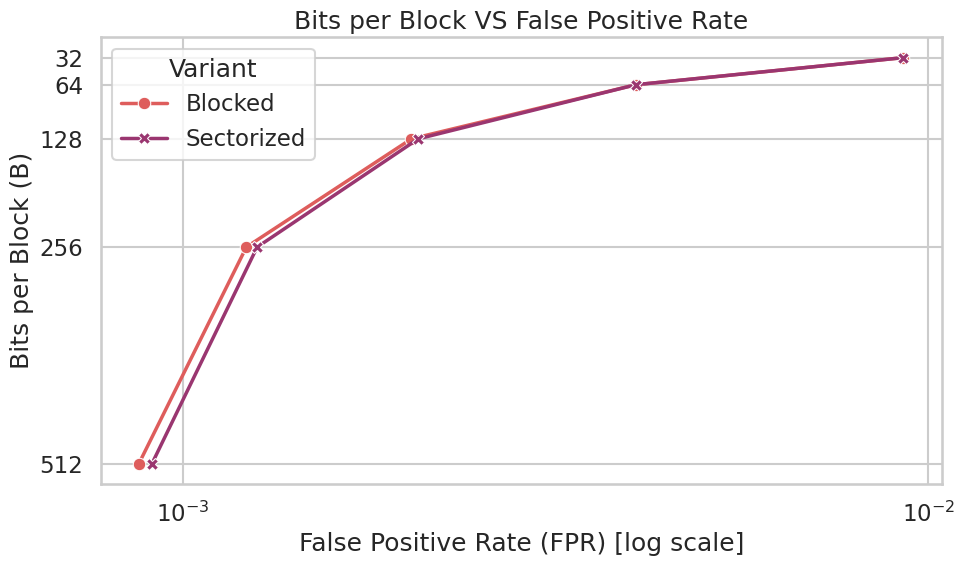

In [10]:
# Example w/ plot
k = 8
m_over_n = 2 * k
B_values = [32, 64, 128, 256, 512]
blocked_values = [theoretical_fpr_blocked(
    m_over_n, k, B) for B in B_values]
sectorized_values = [theoretical_fpr_sectorized(
    m_over_n, k, B, B if B == 32 else 64) for B in B_values]

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.set_context("talk")
palette = sns.color_palette("flare", n_colors=2)

df = pd.DataFrame({
    'Bits per Block (B)': B_values * 2,
    'False Positive Rate (FPR)': blocked_values + sectorized_values,
    'Variant': ['Blocked'] * len(blocked_values) + ['Sectorized'] * len(sectorized_values)})

sns.lineplot(data=df,
             x='False Positive Rate (FPR)',
             y='Bits per Block (B)',
             sort=False,
             hue='Variant',
             style='Variant',
             markers=True,
             dashes=False,
             linewidth=2.5,
             palette=palette)

plt.xscale('log')
plt.yticks(B_values)
plt.gca().invert_yaxis()
plt.title('Bits per Block VS False Positive Rate')
plt.ylabel('Bits per Block (B)')
plt.xlabel('False Positive Rate (FPR) [log scale]')
plt.tight_layout()

plt.show()